# Wafer Anomaly Detection — Optimized PatchCore (Wide ResNet-50-2)

Based on the PatchCore V2 pipeline, upgraded to **Wide ResNet-50-2**.

| Component | Baseline (50k) | V2 ResNet-18 | **This notebook** |
|---|---|---|---|
| Backbone | ResNet-18 | ResNet-18 | **Wide ResNet-50-2** |
| Patch NN | 1-NN | k=3 averaged | **k=3 averaged** |
| Patch aggregation | max | top-5% mean | **top-5% mean** |
| Score normalization | raw | z-score | **z-score** |
| Threshold tuning set | test (leaky) | tune split | **tune split** |
| Per-class recall | ✗ | ✓ | **✓** |
| Score persistence | ✗ | ✓ (.npz) | **✓ (.npz)** |

Pipeline:
1. Load & clean WM-811K wafer data
2. Split: 50k train-normal / 2.5k tune-normal / 2.5k tune-defect / 5k test-normal / 2.5k test-defect
3. Extract multi-scale patch embeddings from frozen Wide ResNet-50-2 (layer2 ⊕ layer3)
4. Build PatchCore memory bank (subsampled, normalized)
5. Score via k-NN patch distances; z-normalize; save to `.npz`
6. Tune threshold exclusively on tune split
7. Final evaluation on held-out test split (confusion matrix, ROC-AUC, per-class recall)


In [1]:
# Core imports
import os
import gc
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from torchvision.models import wide_resnet50_2, Wide_ResNet50_2_Weights
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = DEVICE.type == 'cuda'
if USE_CUDA:
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')

print('Using device:', DEVICE)

Using device: cuda


In [2]:
# Configuration
DATA_PATH = '../data/raw/LSWMD.pkl'
IMAGE_SIZE = 128

NUM_WORKERS = 0
PIN_MEMORY = USE_CUDA
PERSISTENT_WORKERS = False
PREFETCH_FACTOR = None
BATCH_SIZE = 64 if USE_CUDA else 24

# Dataset splits — tune split is used for threshold selection (test set is never seen during tuning)
TRAIN_NORMAL_N = 20000
TUNE_NORMAL_N  = 2500
TUNE_DEFECT_N  = 2500
TEST_NORMAL_N  = 5000
TEST_DEFECT_N  = 2500

# Wide ResNet PatchCore settings
PATCHCORE_NN_K         = 3      # k nearest neighbors per patch (averaged → less noise)
TOPK_PATCH_RATIO       = 0.05   # fraction of top-scoring patches used for image score
MEMORY_BANK_MAX_PATCHES = 240000 if USE_CUDA else 50000
SCORE_CHUNK            = 2048 if USE_CUDA else 512
USE_AMP                = USE_CUDA

ARTIFACT_DIR        = '../artifacts/x64/patchcore_wideresnet50_optimized'
MODEL_EXPORT_PATH   = os.path.join(ARTIFACT_DIR, 'patchcore_model.pt')
METRICS_EXPORT_PATH = os.path.join(ARTIFACT_DIR, 'evaluation_metrics.json')
SCORES_EXPORT_PATH  = os.path.join(ARTIFACT_DIR, 'scores.npz')
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(
    f'image={IMAGE_SIZE}, batch={BATCH_SIZE}, workers={NUM_WORKERS}, amp={USE_AMP}\n'
    f'bank_max={MEMORY_BANK_MAX_PATCHES}, chunk={SCORE_CHUNK}, '
    f'nn_k={PATCHCORE_NN_K}, topk_ratio={TOPK_PATCH_RATIO}\n'
    f'artifacts={ARTIFACT_DIR}'
)


image=128, batch=64, workers=0, amp=True
bank_max=240000, chunk=2048, nn_k=3, topk_ratio=0.05
artifacts=../artifacts/x64/patchcore_wideresnet50_optimized


In [3]:
# Load and clean labels
df = pd.read_pickle(DATA_PATH)
print('Raw shape:', df.shape)

def parse_failure_label(value):
    if value is None:
        return 'unknown'
    if isinstance(value, float) and np.isnan(value):
        return 'unknown'
    if isinstance(value, (list, tuple, np.ndarray)):
        arr = np.array(value).reshape(-1)
        if len(arr) == 0:
            return 'unknown'
        return str(arr[0])
    return str(value)

df = df.copy()
df['failure_label'] = df['failureType'].apply(parse_failure_label).astype(str).str.strip()
invalid = {'0', 'unknown', 'nan', 'None', '[]'}
df = df[~df['failure_label'].isin(invalid)].copy()
df['is_anomaly'] = (df['failure_label'].str.lower() != 'none').astype(int)

normal_df = df[df['is_anomaly'] == 0].copy()
defect_df = df[df['is_anomaly'] == 1].copy()

print('Labeled shape:', df.shape)
print('Normal wafers:', len(normal_df))
print('Defect wafers:', len(defect_df))

Raw shape: (811457, 6)
Labeled shape: (172950, 8)
Normal wafers: 147431
Defect wafers: 25519


In [4]:
# Enforce split sizes: 50k train-normal / 2.5k tune-normal / 2.5k tune-defect / 5k test-normal / 2.5k test-defect
required_normals = TRAIN_NORMAL_N + TUNE_NORMAL_N + TEST_NORMAL_N
required_defects = TUNE_DEFECT_N + TEST_DEFECT_N

if len(normal_df) < required_normals:
    raise ValueError(f'Not enough normal wafers: need {required_normals}, found {len(normal_df)}')
if len(defect_df) < required_defects:
    raise ValueError(f'Not enough defect wafers: need {required_defects}, found {len(defect_df)}')

rng = np.random.default_rng(SEED)
normal_df_shuf = normal_df.iloc[rng.permutation(len(normal_df))].reset_index(drop=True)
defect_df_shuf = defect_df.iloc[rng.permutation(len(defect_df))].reset_index(drop=True)

n0, n1 = 0, TRAIN_NORMAL_N
n2 = n1 + TUNE_NORMAL_N
n3 = n2 + TEST_NORMAL_N

train_normal_df = normal_df_shuf.iloc[n0:n1].copy()
tune_normal_df  = normal_df_shuf.iloc[n1:n2].copy()
test_normal_df  = normal_df_shuf.iloc[n2:n3].copy()

d0, d1 = 0, TUNE_DEFECT_N
d2 = d1 + TEST_DEFECT_N

tune_defect_df = defect_df_shuf.iloc[d0:d1].copy()
test_defect_df = defect_df_shuf.iloc[d1:d2].copy()

print('Train normal:', len(train_normal_df))
print('Tune normal:', len(tune_normal_df), '| Tune defect:', len(tune_defect_df))
print('Test normal:', len(test_normal_df), '| Test defect:', len(test_defect_df))


Train normal: 20000
Tune normal: 2500 | Tune defect: 2500
Test normal: 5000 | Test defect: 2500


In [5]:
# Wafer map -> 3ch tensor
def wafer_to_tensor(wafer_map, size=128):
    arr = np.array(wafer_map, dtype=np.int64)
    arr = np.clip(arr, 0, 2)
    x = torch.tensor(arr, dtype=torch.long)
    x = F.one_hot(x, num_classes=3).permute(2, 0, 1).float()
    x = x.unsqueeze(0)
    x = F.interpolate(x, size=(size, size), mode='nearest')
    return x.squeeze(0)

def build_tensor(frame, size=128):
    imgs = [wafer_to_tensor(w, size=size) for w in frame['waferMap'].values]
    X = torch.stack(imgs)
    y = torch.tensor(frame['is_anomaly'].values, dtype=torch.long)
    return X, y

X_train,       y_train       = build_tensor(train_normal_df, IMAGE_SIZE)
X_tune_normal, y_tune_normal = build_tensor(tune_normal_df,  IMAGE_SIZE)
X_tune_defect, y_tune_defect = build_tensor(tune_defect_df,  IMAGE_SIZE)
X_test_normal, y_test_normal = build_tensor(test_normal_df,  IMAGE_SIZE)
X_test_defect, y_test_defect = build_tensor(test_defect_df,  IMAGE_SIZE)

print('X_train:', tuple(X_train.shape))
print('X_tune_normal:', tuple(X_tune_normal.shape), '| X_tune_defect:', tuple(X_tune_defect.shape))
print('X_test_normal:', tuple(X_test_normal.shape), '| X_test_defect:', tuple(X_test_defect.shape))


X_train: (20000, 3, 128, 128)
X_tune_normal: (2500, 3, 128, 128) | X_tune_defect: (2500, 3, 128, 128)
X_test_normal: (5000, 3, 128, 128) | X_test_defect: (2500, 3, 128, 128)


In [6]:
# DataLoaders
loader_kwargs = {
    'batch_size': BATCH_SIZE,
    'shuffle': False,
    'num_workers': NUM_WORKERS,
    'pin_memory': PIN_MEMORY,
}
if NUM_WORKERS > 0:
    loader_kwargs['persistent_workers'] = PERSISTENT_WORKERS
    loader_kwargs['prefetch_factor'] = PREFETCH_FACTOR

train_loader       = DataLoader(TensorDataset(X_train,       y_train),       **loader_kwargs)
tune_normal_loader = DataLoader(TensorDataset(X_tune_normal, y_tune_normal), **loader_kwargs)
tune_defect_loader = DataLoader(TensorDataset(X_tune_defect, y_tune_defect), **loader_kwargs)
test_normal_loader = DataLoader(TensorDataset(X_test_normal, y_test_normal), **loader_kwargs)
test_defect_loader = DataLoader(TensorDataset(X_test_defect, y_test_defect), **loader_kwargs)

print('Train batches:', len(train_loader))
print('Tune normal batches:', len(tune_normal_loader), '| Tune defect batches:', len(tune_defect_loader))
print('Test normal batches:', len(test_normal_loader), '| Test defect batches:', len(test_defect_loader))


Train batches: 313
Tune normal batches: 40 | Tune defect batches: 40
Test normal batches: 79 | Test defect batches: 40


In [7]:
# PatchCore feature extractor from pretrained Wide ResNet-50-2
class WidePatchFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = wide_resnet50_2(weights=Wide_ResNet50_2_Weights.DEFAULT)
        self.stem = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        f2 = self.layer2(x)
        f3 = self.layer3(f2)
        return f2, f3

extractor = WidePatchFeatureExtractor().to(DEVICE).eval()
for p in extractor.parameters():
    p.requires_grad = False

def patch_embeddings(xb):
    with torch.inference_mode():
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_AMP):
            f2, f3 = extractor(xb)
            f3_up = F.interpolate(f3, size=f2.shape[-2:], mode='bilinear', align_corners=False)
            emb = torch.cat([f2, f3_up], dim=1)
            emb = emb.permute(0, 2, 3, 1).reshape(-1, emb.size(1))
        emb = F.normalize(emb.float(), p=2, dim=1)
    return emb

In [8]:
# Build memory bank from train-normal patches with global subsampling
sampled_patches = []
estimated_total_patches = None
sample_ratio = 1.0

with torch.inference_mode():
    for xb, _ in train_loader:
        xb = xb.to(DEVICE, non_blocking=PIN_MEMORY)
        emb = patch_embeddings(xb)

        if estimated_total_patches is None:
            patches_per_image = len(emb) // len(xb)
            estimated_total_patches = patches_per_image * len(train_normal_df)
            sample_ratio = min(1.0, MEMORY_BANK_MAX_PATCHES / estimated_total_patches)
            print('Estimated raw memory bank patches:', estimated_total_patches)
            print('Sampling ratio:', round(sample_ratio, 6))

        if sample_ratio < 1.0:
            keep_n = max(1, int(round(len(emb) * sample_ratio)))
            keep_idx = torch.randperm(len(emb), device=DEVICE)[:keep_n]
            emb = emb[keep_idx]

        sampled_patches.append(emb)

memory_bank = torch.cat(sampled_patches, dim=0)
if len(memory_bank) > MEMORY_BANK_MAX_PATCHES:
    keep_idx = torch.randperm(len(memory_bank), device=DEVICE)[:MEMORY_BANK_MAX_PATCHES]
    memory_bank = memory_bank[keep_idx]

memory_bank = F.normalize(memory_bank, p=2, dim=1).contiguous()
memory_bank_t = memory_bank.t().contiguous()
print('Final memory bank patches:', len(memory_bank), '| Emb dim:', memory_bank.shape[1])

Estimated raw memory bank patches: 5120000
Sampling ratio: 0.046875
Final memory bank patches: 240000 | Emb dim: 1536


In [9]:
# PatchCore scoring: k-NN patch distances + ratio-based top-k aggregation + z-score normalization
def min_dist_to_bank(patches, bank_t, chunk=2048, nn_k=1):
    """Mean Euclidean distance to the k nearest memory-bank embeddings (L2-normalized space)."""
    mins = []
    for i in range(0, len(patches), chunk):
        p = patches[i:i + chunk]
        sim = p @ bank_t
        k = min(nn_k, sim.shape[1])
        best_sim = sim.topk(k=k, dim=1).values
        dist = torch.sqrt(torch.clamp(2.0 - 2.0 * best_sim, min=0.0))
        mins.append(dist.mean(dim=1))
    return torch.cat(mins, dim=0)

def score_loader(loader, bank_t, topk_patch_ratio=0.05, nn_k=1):
    img_scores = []
    with torch.inference_mode():
        for xb, _ in loader:
            xb = xb.to(DEVICE, non_blocking=PIN_MEMORY)
            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_AMP):
                f2, f3 = extractor(xb)
                f3_up = F.interpolate(f3, size=f2.shape[-2:], mode='bilinear', align_corners=False)
                emb = torch.cat([f2, f3_up], dim=1)
                emb = emb.permute(0, 2, 3, 1)
                b, h, w, c = emb.shape
                emb = emb.reshape(-1, c)
            emb = F.normalize(emb.float(), p=2, dim=1)

            patch_scores = min_dist_to_bank(emb, bank_t, chunk=SCORE_CHUNK, nn_k=nn_k)
            patch_scores = patch_scores.reshape(b, h * w)
            topk_patches = max(1, int(round(patch_scores.shape[1] * topk_patch_ratio)))
            topk_patches = min(topk_patches, patch_scores.shape[1])
            score = patch_scores.topk(k=topk_patches, dim=1).values.mean(dim=1)
            img_scores.append(score.cpu())

    return torch.cat(img_scores).numpy()

train_scores       = score_loader(train_loader,       memory_bank_t, TOPK_PATCH_RATIO, PATCHCORE_NN_K)
tune_normal_scores = score_loader(tune_normal_loader, memory_bank_t, TOPK_PATCH_RATIO, PATCHCORE_NN_K)
tune_defect_scores = score_loader(tune_defect_loader, memory_bank_t, TOPK_PATCH_RATIO, PATCHCORE_NN_K)
test_normal_scores = score_loader(test_normal_loader, memory_bank_t, TOPK_PATCH_RATIO, PATCHCORE_NN_K)
test_defect_scores = score_loader(test_defect_loader, memory_bank_t, TOPK_PATCH_RATIO, PATCHCORE_NN_K)

# Z-score normalization using train-normal statistics for stable, reproducible thresholds
train_score_mu  = float(np.mean(train_scores))
train_score_std = float(np.std(train_scores) + 1e-8)

train_scores_z       = (train_scores       - train_score_mu) / train_score_std
tune_normal_scores_z = (tune_normal_scores - train_score_mu) / train_score_std
tune_defect_scores_z = (tune_defect_scores - train_score_mu) / train_score_std
test_normal_scores_z = (test_normal_scores - train_score_mu) / train_score_std
test_defect_scores_z = (test_defect_scores - train_score_mu) / train_score_std

np.savez_compressed(
    SCORES_EXPORT_PATH,
    train_scores_z=train_scores_z,
    tune_normal_scores_z=tune_normal_scores_z,
    tune_defect_scores_z=tune_defect_scores_z,
    test_normal_scores_z=test_normal_scores_z,
    test_defect_scores_z=test_defect_scores_z,
    train_score_mu=np.array([train_score_mu]),
    train_score_std=np.array([train_score_std]),
)

print(f'Scoring config: nn_k={PATCHCORE_NN_K}, topk_ratio={TOPK_PATCH_RATIO}')
print(f'Train-normal normalization: mu={train_score_mu:.6f}, std={train_score_std:.6f}')
print('Scores saved to:', SCORES_EXPORT_PATH)


Scoring config: nn_k=3, topk_ratio=0.05
Train-normal normalization: mu=0.453410, std=0.022922
Scores saved to: ../artifacts/x64/patchcore_wideresnet50_optimized\scores.npz


In [10]:
# Reload scores from disk — run this cell instead of the scoring cell if scores are already saved
with np.load(SCORES_EXPORT_PATH) as data:
    train_scores_z       = data['train_scores_z']
    tune_normal_scores_z = data['tune_normal_scores_z']
    tune_defect_scores_z = data['tune_defect_scores_z']
    test_normal_scores_z = data['test_normal_scores_z']
    test_defect_scores_z = data['test_defect_scores_z']
    train_score_mu       = float(data['train_score_mu'][0])
    train_score_std      = float(data['train_score_std'][0])

print('Score arrays loaded from:', SCORES_EXPORT_PATH)
print('  train:', train_scores_z.shape)
print('  tune_normal:', tune_normal_scores_z.shape, '| tune_defect:', tune_defect_scores_z.shape)
print('  test_normal:', test_normal_scores_z.shape, '| test_defect:', test_defect_scores_z.shape)
print(f'  Normalization: mu={train_score_mu:.6f}, std={train_score_std:.6f}')


Score arrays loaded from: ../artifacts/x64/patchcore_wideresnet50_optimized\scores.npz
  train: (20000,)
  tune_normal: (2500,) | tune_defect: (2500,)
  test_normal: (5000,) | test_defect: (2500,)
  Normalization: mu=0.453410, std=0.022922


Tuned z-threshold: 1.090514 (raw: 0.478407)
Precision=0.8452 | Recall=0.7272 | F1=0.7818 | Balanced Acc=0.7970


,threshold_z,precision,recall,f1,specificity,balanced_accuracy,fp,fn
0,1.090514,0.845188,0.7272,0.781767,0.8668,0.7970,333,682
1,1.244964,0.869955,0.6984,0.774795,0.8956,0.7970,261,754
2,0.936064,0.821195,0.7532,0.785729,0.8360,0.7946,410,617
3,1.399415,0.891689,0.6652,0.761970,0.9192,0.7922,202,837
4,1.553865,0.909774,0.6292,0.743911,0.9376,0.7834,156,927
5,0.781614,0.784187,0.7776,0.780880,0.7860,0.7818,535,556
6,1.638450,0.914030,0.6124,0.733413,0.9424,0.7774,144,969
7,1.648670,0.914817,0.6100,0.731941,0.9432,0.7766,142,975
8,1.664769,0.916313,0.6044,0.728368,0.9448,0.7746,138,989
9,1.681773,0.917683,0.6020,0.727053,0.9460,0.7740,135,995


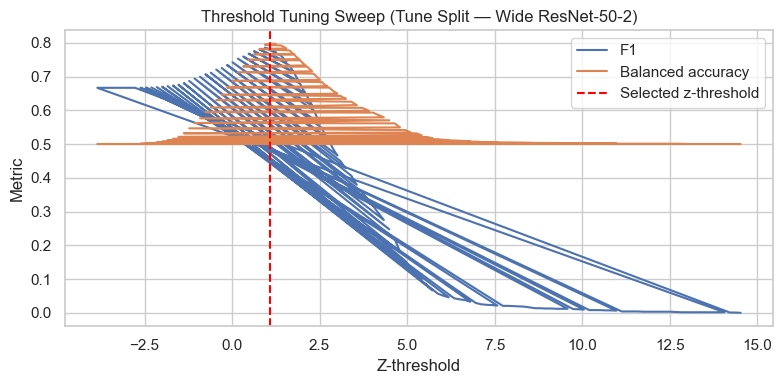

Run the next evaluation cell to report final test metrics with the tuned threshold.


In [11]:
# Tune threshold on the labeled tune split (test set is never seen here)
y_tune = np.concatenate([
    np.zeros(len(tune_normal_scores_z), dtype=int),
    np.ones(len(tune_defect_scores_z), dtype=int),
])
score_tune = np.concatenate([tune_normal_scores_z, tune_defect_scores_z])

candidate_thresholds = np.unique(
    np.concatenate([
        np.percentile(train_scores_z, np.linspace(95.0, 99.9, 40)),
        np.linspace(score_tune.min(), score_tune.max(), 120),
    ])
)

rows = []
for candidate in candidate_thresholds:
    pred = (score_tune > candidate).astype(int)
    tp = int(((pred == 1) & (y_tune == 1)).sum())
    tn = int(((pred == 0) & (y_tune == 0)).sum())
    fp = int(((pred == 1) & (y_tune == 0)).sum())
    fn = int(((pred == 0) & (y_tune == 1)).sum())

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    balanced_accuracy = 0.5 * (recall + specificity)

    rows.append({
        'threshold_z': float(candidate),
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'specificity': specificity,
        'balanced_accuracy': balanced_accuracy,
        'fp': fp,
        'fn': fn,
    })

threshold_tuning = pd.DataFrame(rows).sort_values(
    ['balanced_accuracy', 'f1', 'precision', 'threshold_z'],
    ascending=[False, False, False, True],
).reset_index(drop=True)

best_row = threshold_tuning.iloc[0]
threshold_z   = float(best_row['threshold_z'])
threshold_raw = train_score_mu + threshold_z * train_score_std

print(f'Tuned z-threshold: {threshold_z:.6f} (raw: {threshold_raw:.6f})')
print(
    f"Precision={best_row['precision']:.4f} | Recall={best_row['recall']:.4f} | "
    f"F1={best_row['f1']:.4f} | Balanced Acc={best_row['balanced_accuracy']:.4f}"
)
display(threshold_tuning.head(10))

plt.figure(figsize=(8, 4))
plt.plot(threshold_tuning['threshold_z'], threshold_tuning['f1'], label='F1')
plt.plot(threshold_tuning['threshold_z'], threshold_tuning['balanced_accuracy'], label='Balanced accuracy')
plt.axvline(threshold_z, color='red', linestyle='--', label=f'Selected z-threshold')
plt.xlabel('Z-threshold')
plt.ylabel('Metric')
plt.title('Threshold Tuning Sweep (Tune Split — Wide ResNet-50-2)')
plt.legend()
plt.tight_layout()
plt.show()

print('Run the next evaluation cell to report final test metrics with the tuned threshold.')


ROC-AUC (z-score): 0.8670
Applied z-threshold: 1.090514 | raw threshold: 0.478407
              precision    recall  f1-score   support

      normal       0.86      0.86      0.86      5000
     anomaly       0.72      0.73      0.72      2500

    accuracy                           0.82      7500
   macro avg       0.79      0.79      0.79      7500
weighted avg       0.82      0.82      0.82      7500



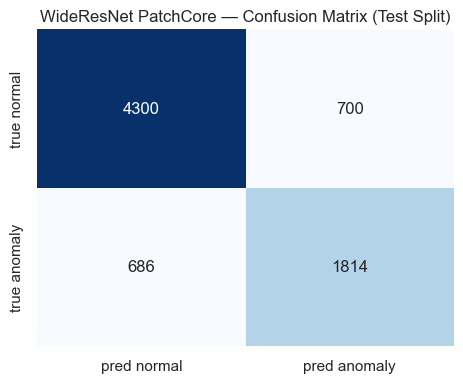

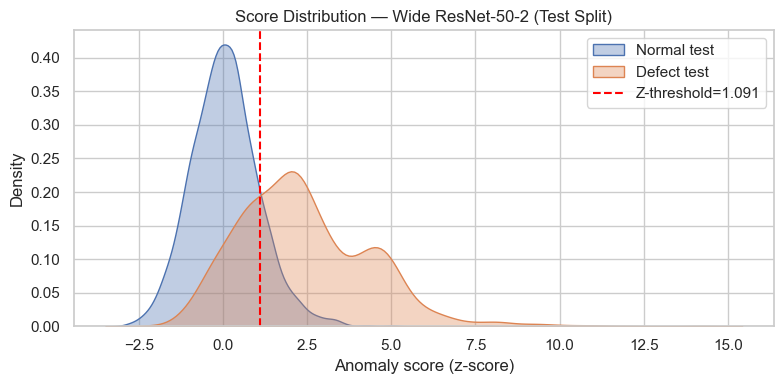


Per-defect-class recall:


,count,detected,recall,mean_score
failure_label,,,,
Center,419,156,0.372,1.206
Edge-Loc,471,277,0.588,1.674
Loc,355,217,0.611,1.877
Scratch,127,104,0.819,3.790
Random,89,80,0.899,3.476
Near-full,16,15,0.938,3.535
Edge-Ring,959,902,0.941,3.031
Donut,64,63,0.984,3.656


Saved model artifact to: ../artifacts/x64/patchcore_wideresnet50_optimized\patchcore_model.pt
Saved metrics to: ../artifacts/x64/patchcore_wideresnet50_optimized\evaluation_metrics.json
Memory cleared (Python GC + CUDA cache).


In [12]:
# Final evaluation on held-out test split (never seen during threshold tuning)
y_true = np.concatenate([
    np.zeros(len(test_normal_scores_z), dtype=int),
    np.ones(len(test_defect_scores_z), dtype=int),
])
scores = np.concatenate([test_normal_scores_z, test_defect_scores_z])
y_pred = (scores > threshold_z).astype(int)

roc_auc = float(roc_auc_score(y_true, scores))
report  = classification_report(y_true, y_pred, target_names=['normal', 'anomaly'])
cm      = confusion_matrix(y_true, y_pred)

print(f'ROC-AUC (z-score): {roc_auc:.4f}')
print(f'Applied z-threshold: {threshold_z:.6f} | raw threshold: {threshold_raw:.6f}')
print(report)

plt.figure(figsize=(4.8, 4.0))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pred normal', 'pred anomaly'],
            yticklabels=['true normal', 'true anomaly'])
plt.title('WideResNet PatchCore — Confusion Matrix (Test Split)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.kdeplot(test_normal_scores_z, label='Normal test', fill=True, alpha=0.35)
sns.kdeplot(test_defect_scores_z, label='Defect test', fill=True, alpha=0.35)
plt.axvline(threshold_z, color='red', linestyle='--', label=f'Z-threshold={threshold_z:.3f}')
plt.xlabel('Anomaly score (z-score)')
plt.ylabel('Density')
plt.title('Score Distribution — Wide ResNet-50-2 (Test Split)')
plt.legend()
plt.tight_layout()
plt.show()

# Per-defect-class recall
tmp = test_defect_df.copy()
tmp['score']    = test_defect_scores_z
tmp['detected'] = (test_defect_scores_z > threshold_z).astype(int)
print('\nPer-defect-class recall:')
display(
    tmp.groupby('failure_label').agg(
        count=('detected', 'count'),
        detected=('detected', 'sum'),
        recall=('detected', 'mean'),
        mean_score=('score', 'mean'),
    ).round(3).sort_values('recall')
)

# Save artifacts
artifact = {
    'extractor_state_dict': extractor.state_dict(),
    'threshold_z':     float(threshold_z),
    'threshold_raw':   float(threshold_raw),
    'train_score_mu':  float(train_score_mu),
    'train_score_std': float(train_score_std),
    'config': {
        'image_size':            IMAGE_SIZE,
        'train_normal_n':        TRAIN_NORMAL_N,
        'tune_normal_n':         TUNE_NORMAL_N,
        'tune_defect_n':         TUNE_DEFECT_N,
        'test_normal_n':         TEST_NORMAL_N,
        'test_defect_n':         TEST_DEFECT_N,
        'memory_bank_max_patches': MEMORY_BANK_MAX_PATCHES,
        'score_chunk':           SCORE_CHUNK,
        'patchcore_nn_k':        PATCHCORE_NN_K,
        'topk_patch_ratio':      TOPK_PATCH_RATIO,
    },
}
torch.save(artifact, MODEL_EXPORT_PATH)

metrics = {
    'roc_auc_z':       roc_auc,
    'threshold_z':     float(threshold_z),
    'threshold_raw':   float(threshold_raw),
    'train_score_mu':  float(train_score_mu),
    'train_score_std': float(train_score_std),
    'confusion_matrix': cm.tolist(),
    'n_test_normal':   int(len(test_normal_scores_z)),
    'n_test_defect':   int(len(test_defect_scores_z)),
}
pd.Series(metrics).to_json(METRICS_EXPORT_PATH, indent=2)

print('Saved model artifact to:', MODEL_EXPORT_PATH)
print('Saved metrics to:', METRICS_EXPORT_PATH)

# Release RAM / VRAM
vars_to_clear = [
    'X_train', 'X_tune_normal', 'X_tune_defect', 'X_test_normal', 'X_test_defect',
    'y_train', 'y_tune_normal', 'y_tune_defect', 'y_test_normal', 'y_test_defect',
    'sampled_patches', 'memory_bank', 'memory_bank_t',
    'train_scores', 'tune_normal_scores', 'tune_defect_scores',
    'test_normal_scores', 'test_defect_scores',
    'train_scores_z', 'tune_normal_scores_z', 'tune_defect_scores_z',
    'test_normal_scores_z', 'test_defect_scores_z',
    'scores', 'y_true', 'y_pred',
    'train_loader', 'tune_normal_loader', 'tune_defect_loader',
    'test_normal_loader', 'test_defect_loader',
]
for name in vars_to_clear:
    if name in globals():
        del globals()[name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print('Memory cleared (Python GC + CUDA cache).')


## Notes

- If CUDA runs out of memory, reduce `BATCH_SIZE` first, then `SCORE_CHUNK`.
- `IMAGE_SIZE=128` is a practical default for Wide ResNet on mid-range GPUs.
- You can adjust `TOPK_PATCH` and `TOPK_TEMP` to tune sensitivity to localized defects.